# 04 · Optimizer backtest, 2025-26 GW5–38

Does better forecasting turn into more FPL points once an optimizer makes the decisions?

| Strategy | Squad / transfers | Predictions |
|---|---|---|
| **A** | squad ILP at GW5, then the transfer planner (≤ 1 free transfer per GW) | walk-forward LightGBM |
| **B** | same optimizer | rolling-form baseline B0 |
| **C** | greedy points-per-£ squad, then the best single like-for-like swap | walk-forward LightGBM |

Rules: £100m at GW5 with the real GW5 prices (`value`), real price changes after that, sold at the
current price, no hits, no chips, horizon N = 3 (discount 0.9). Every GW k prediction comes from
the walk-forward fold trained only on data before GW k; for GW k+1 and k+2 the horizon uses the
player's latest per-fixture prediction × his club's fixture count (the published schedule), so
no future form leaks in. Scoring: actual points of the XI, simplified auto-subs, captain doubled
(vice if the captain didn't play).

Regenerate with `python -m fPLense.pipeline --backtest` (about 2 minutes).

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from fPLense import config
from fPLense.optimize import backtest

pd.set_option("display.width", 140)
per_path = config.EVAL_DIR / "backtest_per_gw.parquet"
if per_path.exists() and config.BACKTEST_PATH.exists():
    per_gw = pd.read_parquet(per_path)
    summary = json.loads(config.BACKTEST_PATH.read_text(encoding="utf-8"))
else:
    result = backtest.run_backtest()
    per_gw, summary = result.per_gw, result.summary
labels = {k: v["label"] for k, v in backtest.STRATEGIES.items()}

## Season totals

In [2]:
totals = per_gw.groupby("strategy").agg(
    points=("points", "sum"),
    per_gw=("points", "mean"),
    best_gw=("points", "max"),
    worst_gw=("points", "min"),
    transfers=("transfers", "sum"),
    auto_subs=("auto_subs", "sum"),
    avg_bank=("bank", "mean"),
)
totals.index = totals.index.map(labels)
print(totals.sort_values("points", ascending=False).round(1).to_string())
print()
for key in ("a_minus_b", "a_minus_c"):
    if key in summary:
        lo, hi = summary[f"{key}_ci95"]
        print(f"{key.replace('_', ' ')}: {summary[key]:+d} points (95% CI over GWs {lo:+.0f} … {hi:+.0f})")
print(f"A ahead of B in {summary['a_beats_b_gws']} of {len(summary['gws'])} gameweeks")

                            points  per_gw  best_gw  worst_gw  transfers  auto_subs  avg_bank
strategy                                                                                     
C: greedy pts/£ + LightGBM    1844    54.2       84        31         33         28      36.6
B: ILP + rolling form (B0)    1826    53.7       90        28         33         47      26.1
A: ILP + LightGBM             1751    51.5       93        26         33         30      24.6

a minus b: -75 points (95% CI over GWs -276 … +118)
a minus c: -93 points (95% CI over GWs -257 … +50)
A ahead of B in 17 of 34 gameweeks


## Cumulative points

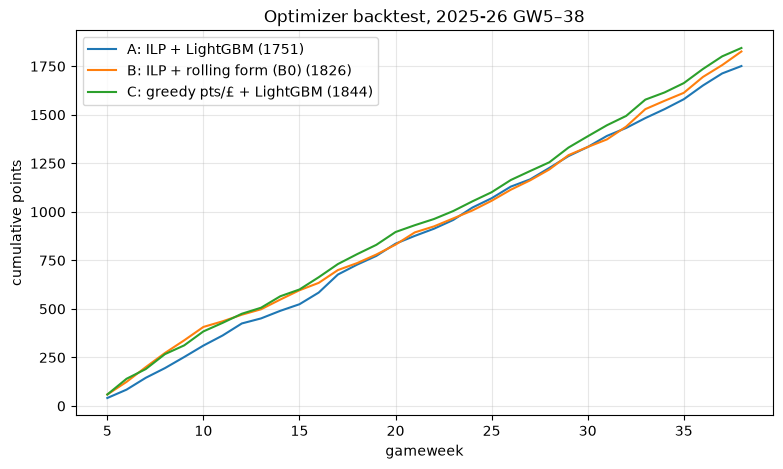

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for s, g in per_gw.groupby("strategy", sort=False):
    ax.plot(g["gw"], g["cum_points"], label=f"{labels[s]} ({g['points'].sum()})")
ax.set_xlabel("gameweek")
ax.set_ylabel("cumulative points")
ax.set_title("Optimizer backtest, 2025-26 GW5–38")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## Gameweek-by-gameweek difference, A − B

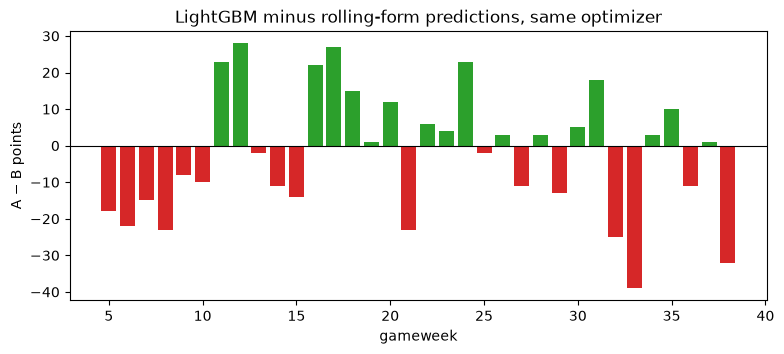

count    34.0
mean     -2.2
std      17.4
min     -39.0
25%     -13.8
50%      -0.5
75%       9.0
max      28.0


In [4]:
wide = per_gw.pivot(index="gw", columns="strategy", values="points")
diff = wide["lgbm"] - wide["b0"]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(diff.index, diff.values, color=["tab:green" if v > 0 else "tab:red" for v in diff.values])
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("gameweek")
ax.set_ylabel("A − B points")
ax.set_title("LightGBM minus rolling-form predictions, same optimizer")
plt.show()
print(diff.describe().round(1).to_string())

## Captains
The armband is worth a second copy of one player's score, so captain choice matters a lot.

In [5]:
caps = (
    per_gw.groupby("strategy")["captain"]
    .agg(lambda s: ", ".join(f"{n} ×{c}" for n, c in s.value_counts().head(4).items()))
    .rename(index=labels)
)
print(caps.to_string())
cap_pts = {}
for s_, g in per_gw.groupby("strategy"):
    cap_pts[labels[s_]] = g["captain"].nunique()
print("distinct captains:", cap_pts)

strategy
B: ILP + rolling form (B0)    Erling Haaland ×6, Gabriel dos Santos Magalhãe...
C: greedy pts/£ + LightGBM    Erling Haaland ×17, Bruno Borges Fernandes ×6,...
A: ILP + LightGBM             Bukayo Saka ×7, Bruno Borges Fernandes ×7, Erl...
distinct captains: {'B: ILP + rolling form (B0)': 20, 'C: greedy pts/£ + LightGBM': 11, 'A: ILP + LightGBM': 13}


## Transfers made by A

In [6]:
print(per_gw[per_gw.strategy == "lgbm"][["gw", "points", "out", "in", "captain"]].to_string(index=False))

 gw  points                              out                               in                captain
  5      41                                                                            Mohamed Salah
  6      43                       Cody Gakpo                   Mohammed Kudus          Mohamed Salah
  7      61                     Hugo Ekitiké                    Ollie Watkins          Ollie Watkins
  8      50             Veljko Milosavljevic                    Nordi Mukiele          Mohamed Salah
  9      57                    Ollie Watkins                    Junior Kroupi          Junior Kroupi
 10      59                     Mitoma Kaoru                      Bukayo Saka            Bukayo Saka
 11      52                 Emmanuel Agbadou                      Reece James            Bukayo Saka
 12      62                   Mohammed Kudus                   Enzo Fernández            Bukayo Saka
 13      26                  Antoine Semenyo                    Morgan Rogers          Morg

**Takeaway:** **the better forecast did not turn into more points here.** A (ILP + LightGBM) scored 1,751, B (same ILP + rolling form) 1,826 and C (greedy + LightGBM) 1,844. A − B = −75 points with a gameweek-bootstrap 95% CI of [−276, +118], and A was ahead in 17 of 34 GWs: the difference is indistinguishable from zero. Week-to-week FPL scores swing by ±15 points, and one season with one path-dependent squad is a single draw, so an 11% lower per-player MAE is far too small an edge to show up in a season total. The backtest also shows A's squad was *less volatile* (SD 12.8 vs 16.1 per GW), with a lower ceiling in its good weeks (75th percentile 60 vs 66). Conclusion, per PLAN §9: **no backtest claim goes on the resume.** Ideas that might change this (stretch goals): rolling free transfers and hits, a per-GW XI in a multi-week ILP, and risk-seeking captaincy (quantile model).